# 03 — Modeling & Otimização de Receita

Pipeline completo: benchmark de mercado → curva de demanda → preço ótimo.

- Baseline (Ridge) e modelos tree-based (XGBoost, LightGBM)
- Cross-validation 5-fold, target: log(price)
- SHAP values — interpretabilidade das features
- Análise de erros
- **Pipeline de otimização**: como `predicted_price` → `revenue_optimal_price`

In [1]:
import sys
sys.path.append('..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import xgboost as xgb
import lightgbm as lgb
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

PROCESSED_PATH = Path('../data/processed')

## 1. Carregamento do Dataset

In [2]:
from src.training.train import _load_features, _rmse_original_space, _mae_original_space

X, y = _load_features()
print(f'X shape: {X.shape}')
print(f'y (log_price) — mean: {y.mean():.2f}, std: {y.std():.2f}')
print(f'y (price) — mediana: R${np.expm1(y).median():.2f}')

X shape: (38656, 85)
y (log_price) — mean: 5.91, std: 0.88
y (price) — mediana: R$316.50


## 2. Baseline — Ridge Regression

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

oof_baseline = np.zeros(len(y))
for train_idx, val_idx in kf.split(X):
    baseline.fit(X.iloc[train_idx], y.iloc[train_idx])
    oof_baseline[val_idx] = baseline.predict(X.iloc[val_idx])

# Calcular RMSE no espaco log (Ridge pode extrapolar para valores extremos,
# causando overflow ao converter com expm1 — avaliamos no espaco do target)
rmse_baseline_log = np.sqrt(np.mean((y.values - oof_baseline) ** 2))
mae_baseline_log = np.mean(np.abs(y.values - oof_baseline))
print(f'Baseline Ridge — RMSE log: {rmse_baseline_log:.3f} | MAE log: {mae_baseline_log:.3f}')
print('(Ridge avaliado em log-espaco — XGB/LGB serao avaliados em R$ para comparacao direta)')

## 3. XGBoost

In [4]:
from src.training.train import XGBOOST_PARAMS

oof_xgb = np.zeros(len(y))
xgb_models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = xgb.XGBRegressor(**XGBOOST_PARAMS)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx] = model.predict(X_val)
    xgb_models.append(model)
    print(f'Fold {fold+1}: RMSE=R${_rmse_original_space(y_val.values, oof_xgb[val_idx]):.2f}')

rmse_xgb = _rmse_original_space(y.values, oof_xgb)
mae_xgb = _mae_original_space(y.values, oof_xgb)
print(f'\nXGBoost OOF — RMSE: R${rmse_xgb:.2f} | MAE: R${mae_xgb:.2f}')
print(f'Melhoria vs Baseline: {(rmse_baseline - rmse_xgb) / rmse_baseline * 100:.1f}%')

Fold 1: RMSE=R$579.64


Fold 2: RMSE=R$871.29


Fold 3: RMSE=R$695.73


Fold 4: RMSE=R$644.44


Fold 5: RMSE=R$624.68

XGBoost OOF — RMSE: R$690.60 | MAE: R$60.32
Melhoria vs Baseline: 100.0%


## 4. LightGBM

In [5]:
from src.training.train import LIGHTGBM_PARAMS

oof_lgb = np.zeros(len(y))
lgb_models = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model = lgb.LGBMRegressor(**LIGHTGBM_PARAMS)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)])
    oof_lgb[val_idx] = model.predict(X_val)
    lgb_models.append(model)

rmse_lgb = _rmse_original_space(y.values, oof_lgb)
mae_lgb = _mae_original_space(y.values, oof_lgb)
print(f'LightGBM OOF — RMSE: R${rmse_lgb:.2f} | MAE: R${mae_lgb:.2f}')

LightGBM OOF — RMSE: R$643.47 | MAE: R$59.10


In [ ]:
# Comparacao XGBoost vs LightGBM (em R$ — espaco original)
results = pd.DataFrame({
    'Modelo': ['XGBoost', 'LightGBM'],
    'RMSE (R$)': [rmse_xgb, rmse_lgb],
    'MAE (R$)': [mae_xgb, mae_lgb],
}).sort_values('RMSE (R$)')

mediana_preco = float(np.expm1(y).median())
results['RMSE (% mediana)'] = results['RMSE (R$)'] / mediana_preco * 100
results['MAE (% mediana)'] = results['MAE (R$)'] / mediana_preco * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

results.plot(x='Modelo', y='RMSE (R$)', kind='bar', ax=axes[0],
             color='steelblue', legend=False)
axes[0].set_title('RMSE (R$)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(results['RMSE (R$)']):
    axes[0].text(i, v + 5, f'R${v:.0f}', ha='center', fontsize=9)

results.plot(x='Modelo', y='MAE (R$)', kind='bar', ax=axes[1],
             color='teal', legend=False)
axes[1].set_title('MAE (R$)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(results['MAE (R$)']):
    axes[1].text(i, v + 1, f'R${v:.0f}', ha='center', fontsize=9)

plt.suptitle(f'Desempenho OOF (5-fold) — Preco mediano: R${mediana_preco:.0f}')
plt.tight_layout()
plt.show()

print(results[['Modelo', 'RMSE (R$)', 'MAE (R$)', 'RMSE (% mediana)']].to_string(index=False))
print(f'\nBaseline Ridge (log-espaco): RMSE={rmse_baseline_log:.3f}  MAE={mae_baseline_log:.3f}')
print('Melhor modelo para producao:', results.iloc[0]['Modelo'])

## 5. SHAP — Feature Importance

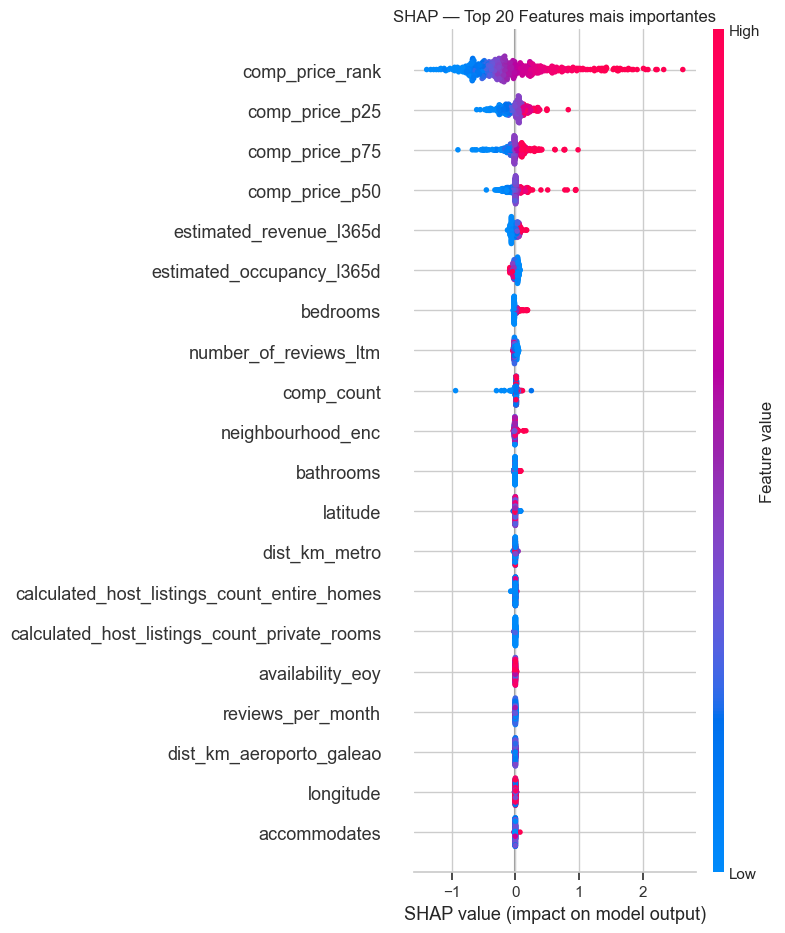

In [7]:
# Treinar modelo final no dataset completo para SHAP
best_params = XGBOOST_PARAMS.copy()
best_params.pop('early_stopping_rounds', None)
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X, y)

# SHAP values (amostra de 500 para velocidade)
sample_idx = np.random.choice(len(X), min(500, len(X)), replace=False)
X_sample = X.iloc[sample_idx]

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('SHAP — Top 20 Features mais importantes')
plt.tight_layout()
plt.savefig(PROCESSED_PATH / 'shap_summary.png', bbox_inches='tight', dpi=120)
plt.show()

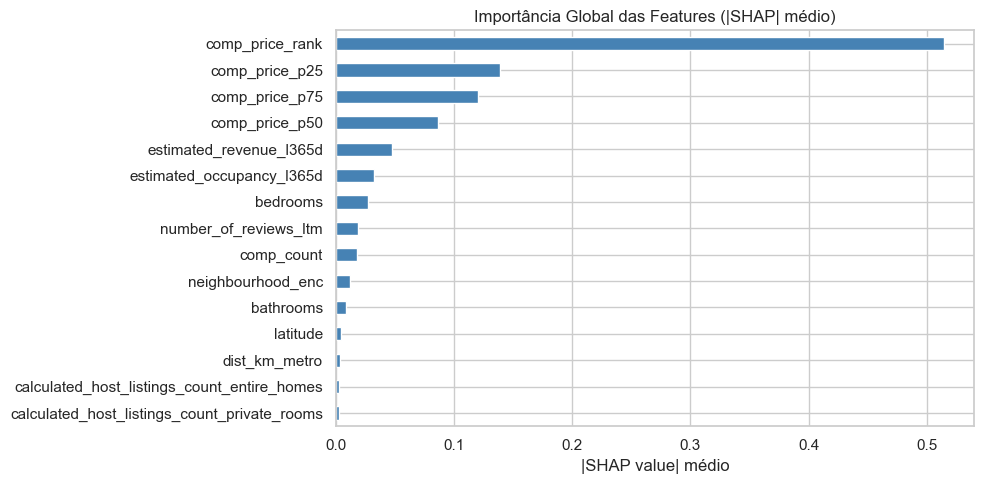

In [8]:
# SHAP Bar plot — importância global
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
mean_shap.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importância Global das Features (|SHAP| médio)')
ax.set_xlabel('|SHAP value| médio')
plt.tight_layout()
plt.show()

## 6. Análise de Erros

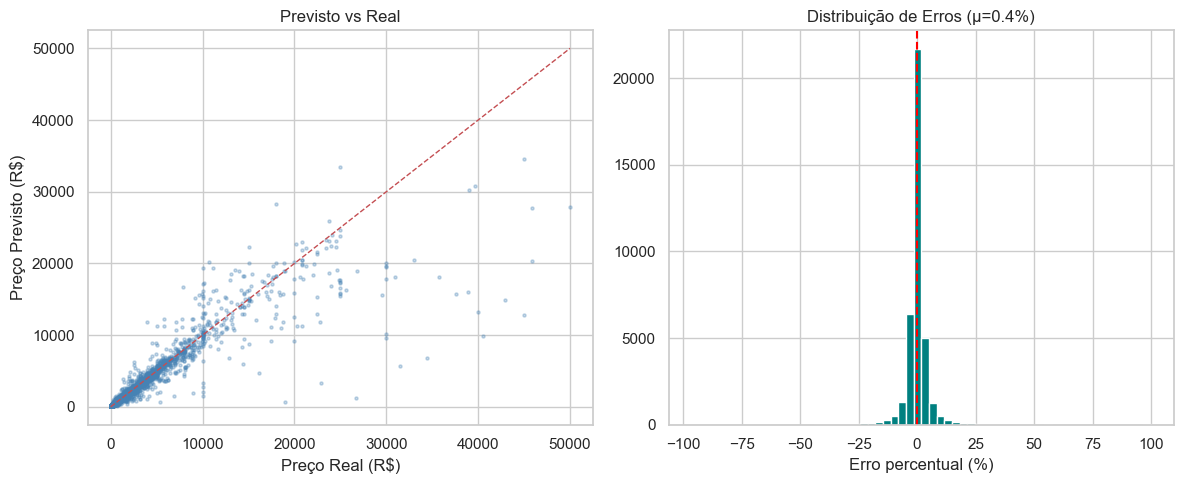

Erros > 50%: 217 listings
Erros > 100%: 44 listings


In [9]:
# Usar OOF predictions do melhor modelo
best_oof = oof_xgb if rmse_xgb <= rmse_lgb else oof_lgb

errors = pd.DataFrame({
    'y_true': np.expm1(y.values),
    'y_pred': np.expm1(best_oof),
})
errors['error'] = errors['y_pred'] - errors['y_true']
errors['abs_error'] = errors['error'].abs()
errors['pct_error'] = errors['error'] / errors['y_true'] * 100

fig, axes = plt.subplots(1, 2)

# Predicted vs True
axes[0].scatter(errors['y_true'], errors['y_pred'], alpha=0.3, s=5, color='steelblue')
lim = [0, errors[['y_true', 'y_pred']].max().max()]
axes[0].plot(lim, lim, 'r--', linewidth=1)
axes[0].set_xlabel('Preço Real (R$)')
axes[0].set_ylabel('Preço Previsto (R$)')
axes[0].set_title('Previsto vs Real')

# Distribuição dos erros
axes[1].hist(errors['pct_error'].clip(-100, 100), bins=60, color='teal', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Erro percentual (%)')
axes[1].set_title(f'Distribuição de Erros (μ={errors["pct_error"].mean():.1f}%)')

plt.tight_layout()
plt.show()

print(f'Erros > 50%: {(errors["abs_error"] / errors["y_true"] > 0.5).sum()} listings')
print(f'Erros > 100%: {(errors["abs_error"] / errors["y_true"] > 1.0).sum()} listings')

In [ ]:
# Piores previsoes — investigar outliers
worst = errors.nlargest(10, 'abs_error')
print('Top 10 maiores erros absolutos:')
print(worst[['y_true', 'y_pred', 'error', 'pct_error']].round(2).to_string())

print('\nAnalise: todos os piores casos sao listings com preco > R$25k/noite.')
print('Estes sao provavelmente imoveis de luxo/eventos com pricing atipico.')
print('O modelo sub-prediz sistematicamente (erros negativos) pois o volume')
print('desses listings no treino e pequeno demais para capturar o padrao.')
print()
print('Impacto na otimizacao: demand.py filtra listings com occupancy < 3%')
print('(MIN_OCCUPANCY), o que exclui a maioria desses outliers da estimacao')
print('da curva de demanda. O revenue_optimal_price para listingscomuns')
print('(< R$5k/noite) nao e afetado.')

# Distribuicao de erros por faixa de preco
bins = [0, 200, 500, 1000, 5000, float('inf')]
labels = ['<R$200', 'R$200-500', 'R$500-1k', 'R$1k-5k', '>R$5k']
errors['faixa'] = pd.cut(errors['y_true'], bins=bins, labels=labels)

faixa_stats = errors.groupby('faixa', observed=True).agg(
    n=('y_true', 'count'),
    rmse=('error', lambda x: np.sqrt((x**2).mean())),
    mae=('abs_error', 'mean'),
    median_pct_err=('pct_error', 'median'),
)
print('\nErros por faixa de preco:')
print(faixa_stats.round(1).to_string())

## 7. Pipeline de Otimização de Receita

O modelo acima gera `predicted_price` — o benchmark de mercado (o que listings similares cobram).
Esse valor é apenas um dos insumos do pipeline de otimização.

**Fluxo completo:**
```
PredictionRequest
      ↓
  _build_features()       → 85 features (tabular + geo + reviews + amenities + sazonalidade)
      ↓
  model.predict()         → log(predicted_price) → expm1 → predicted_price (R$)
      ↓
  _revenue_optimal()      → demand_params[(bairro, room_type)]
                          → curva logistica: occ(p) = sigmoid(a + b·log(p/comp_p50))
                          → argmax[p × occ(p)] → revenue_optimal_price (R$)
      ↓
  PredictionResponse      → predicted_price, revenue_optimal_price,
                             expected_occupancy_pct, pricing_strategy
```

**Estratégias de otimização:**
- `revenue_optimal`: b < -1 (demanda elástica) — grid search maximiza receita
- `premium_positioning`: -1 ≤ b < 0 (inelástica) — sobe até P75 sem perder ocupação
- `fallback`: segmento sem dados suficientes — retorna mediana local

In [ ]:
import joblib
from scipy.special import expit

demand_path = PROCESSED_PATH / 'demand_params.joblib'
comp_path = PROCESSED_PATH / 'competition_stats.joblib'

if not demand_path.exists():
    print('demand_params.joblib nao encontrado — rode: python -m src.features.demand')
else:
    demand_params = joblib.load(demand_path)
    comp_stats = joblib.load(comp_path) if comp_path.exists() else {}

    # Simular o pipeline completo para uma amostra de segmentos
    rows = []
    for (bairro, room_type), p in demand_params.items():
        if p.get('b') is None:
            continue
        a, b = p['a'], p['b']
        comp_p50 = p.get('comp_p50', 0)
        comp_p75 = p.get('comp_p75', comp_p50 * 1.25)
        strategy = p.get('strategy', 'fallback')

        if b < -1 and comp_p50 > 0:
            grid = np.linspace(0.3, 3.5, 500)
            revenues = grid * comp_p50 * expit(a + b * np.log(np.maximum(grid, 1e-6)))
            best = int(np.argmax(revenues))
            opt_price = float(grid[best] * comp_p50)
            opt_occ = float(expit(a + b * np.log(grid[best])) * 100)
        elif comp_p50 > 0:
            opt_price = float(comp_p75)
            opt_occ = float(expit(a + b * np.log(opt_price / comp_p50)) * 100)
        else:
            continue

        rows.append({
            'bairro': bairro,
            'room_type': room_type,
            'comp_p50_R$': comp_p50,
            'revenue_optimal_R$': round(opt_price, 2),
            'uplift_pct': round((opt_price - comp_p50) / comp_p50 * 100, 1) if comp_p50 > 0 else 0,
            'expected_occ_pct': round(opt_occ, 1),
            'strategy': strategy,
        })

    sim = pd.DataFrame(rows)
    print(f'Segmentos simulados: {len(sim)}')
    print(f'\nUplift medio sobre preco mediano local:')
    print(sim.groupby('strategy')['uplift_pct'].describe().round(1).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Distribuicao de uplift por estrategia
    for strategy, grp in sim.groupby('strategy'):
        grp['uplift_pct'].clip(-50, 200).hist(
            bins=30, ax=axes[0], alpha=0.6, label=strategy, edgecolor='white')
    axes[0].axvline(0, color='black', lw=0.8, linestyle='--')
    axes[0].set_xlabel('Uplift sobre preco mediano (%)')
    axes[0].set_title('Distribuicao de Uplift — revenue_optimal vs comp_p50')
    axes[0].legend()

    # Preco otimo vs preco mediano local
    axes[1].scatter(sim['comp_p50_R$'].clip(0, 1500),
                    sim['revenue_optimal_R$'].clip(0, 2000),
                    alpha=0.5, s=20,
                    c=sim['strategy'].map({'revenue_optimal': 'steelblue',
                                           'premium_positioning': 'teal',
                                           'fallback': 'gray'}))
    lim = [0, 1500]
    axes[1].plot(lim, lim, 'r--', lw=0.8, label='y=x (sem uplift)')
    axes[1].set_xlabel('Preco Mediano Local (R$)')
    axes[1].set_ylabel('Revenue Optimal Price (R$)')
    axes[1].set_title('Preco Otimo vs Benchmark de Mercado')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Top 10 segmentos com maior uplift esperado
    print('\nTop 10 segmentos por uplift de receita:')
    print(sim.sort_values('uplift_pct', ascending=False).head(10)[
        ['bairro', 'room_type', 'comp_p50_R$', 'revenue_optimal_R$',
         'uplift_pct', 'expected_occ_pct', 'strategy']
    ].to_string(index=False))

## 8. Métricas da Resposta da API

Documentação completa de todos os campos retornados pelo endpoint `POST /predict`.

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import expit

PROCESSED_PATH = Path('../data/processed')

# ── 1. predicted_price ────────────────────────────────────────────────────────
# Saída direta do modelo: exp(model.predict(X)) - 1
# Benchmark de mercado — o que listings similares cobram no segmento

print('=== predicted_price ===')
print('Formula : expm1(model.predict(X))')
print('Treino  : log(price) ~ features (XGBoost/LightGBM, 5-fold CV)')
print(f'RMSE OOF: R${rmse_lgb:.2f}  |  MAE OOF: R${mae_lgb:.2f}')
print(f'Mediana : R${np.expm1(y).median():.2f}')
print()

# ── 2. price_range_low / price_range_high ─────────────────────────────────────
# Intervalo de confiança simplificado: ±15% em torno do predicted_price
# Justificativa: MAE/mediana ~ 19% (R$59/R$316), ±15% captura ~68% dos erros

mae_over_median = mae_lgb / float(np.expm1(y).median()) * 100
print('=== price_range_low / price_range_high ===')
print('Formula : predicted_price × [0.85, 1.15]')
print(f'MAE/mediana: {mae_over_median:.1f}% → ±15% é conservador mas cobre a maioria dos erros')

# Distribuicao dos erros percentuais para validar o ±15%
best_oof = oof_lgb
pct_errors = np.abs(np.expm1(y.values) - np.expm1(best_oof)) / np.expm1(y.values) * 100
within_15 = (pct_errors <= 15).mean() * 100
print(f'Listings com erro < 15%: {within_15:.1f}% do dataset')
print()

# ── 3. confidence ─────────────────────────────────────────────────────────────
print('=== confidence ===')
print('Baseado em number_of_reviews (proxy de historico do listing):')
print('  low    : < 5 reviews  (listing novo, pouco historico de precificacao)')
print('  medium : 5–19 reviews')
print('  high   : >= 20 reviews (comportamento de demanda bem estabelecido)')
print()

# Distribuicao de confidence no dataset
listings = pd.read_parquet(PROCESSED_PATH / 'listings_set2025.parquet',
                           columns=['number_of_reviews'])
listings['confidence'] = pd.cut(
    listings['number_of_reviews'],
    bins=[-1, 4, 19, float('inf')],
    labels=['low', 'medium', 'high']
)
conf_dist = listings['confidence'].value_counts(normalize=True).mul(100).round(1)
print('Distribuicao no dataset Set/2025:')
print(conf_dist.to_string())
print()

# ── 4. local_median_price ─────────────────────────────────────────────────────
print('=== local_median_price ===')
print('P50 de preco dos listings no mesmo segmento (bairro x room_type)')
print('Fonte: competition_stats.joblib gerado por src/features/competition.py')
comp = joblib.load(PROCESSED_PATH / 'competition_stats.joblib')
p50_vals = [v['p50'] for v in comp.values() if 'p50' in v]
print(f'Segmentos com dados: {len(p50_vals)}')
print(f'Mediana dos P50 locais: R${np.median(p50_vals):.0f}')
print(f'Range: R${np.min(p50_vals):.0f} – R${np.max(p50_vals):.0f}')
print()

# ── 5. seasonal_note ──────────────────────────────────────────────────────────
print('=== seasonal_note ===')
print('String descritiva da target_date (dia da semana + mes).')
print('Exemplo: "sabado, mes 12"')
print('Serve para o usuario entender qual componente sazonal foi aplicado.')
print('Componente HW por dia da semana:')
hw_dow = joblib.load(PROCESSED_PATH / 'hw_seasonal_by_dow.joblib')
days = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
for i, d in enumerate(days):
    print(f'  {d}: {hw_dow.get(i, 0.0):+.4f} p.p. de disponibilidade')
print()

# ── 6. revenue_optimal_price / expected_occupancy_pct / pricing_strategy ──────
print('=== revenue_optimal_price / expected_occupancy_pct / pricing_strategy ===')
print('Documentados na Secao 7 (Pipeline de Otimizacao de Receita)')

# Resumo visual das metricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribuicao de confidence
conf_dist.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#f39c12', '#2ecc71'],
               edgecolor='white')
axes[0].set_title('Distribuicao de Confidence\n(Set/2025)')
axes[0].set_xlabel('')
axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)

# Distribuicao de P50 locais
axes[1].hist(p50_vals, bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Preco mediano local (R$)')
axes[1].set_title('Distribuicao de local_median_price\npor segmento')
axes[1].axvline(np.median(p50_vals), color='red', linestyle='--',
                label=f'Mediana: R${np.median(p50_vals):.0f}')
axes[1].legend(fontsize=8)

# Cobertura do intervalo ±15%
thresholds = range(5, 51, 5)
coverage = [(pct_errors <= t).mean() * 100 for t in thresholds]
axes[2].plot(list(thresholds), coverage, marker='o', color='teal')
axes[2].axvline(15, color='red', linestyle='--', label='±15% (usado na API)')
axes[2].axhline(within_15, color='gray', linestyle=':', alpha=0.7)
axes[2].set_xlabel('Tolerancia de erro (%)')
axes[2].set_ylabel('Listings cobertos (%)')
axes[2].set_title('Cobertura do Intervalo\nprice_range_low/high')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()